In [35]:
import pickle
import numpy as np
import pandas as pd
import importlib

import src.utils.state as state
import src.utils.plottings as plotting
import src.utils.models as models
from src.utils.scenarios import Scenarios
from src.utils.state import NR_TIMESTEPS

importlib.reload(models)
importlib.reload(plotting)

<module 'src.utils.plottings' from 'C:\\Users\\CSURITA\\PycharmProjects\\PythonProject\\counterfactual-analysis-vzv\\src\\utils\\plottings.py'>

In [36]:
Scenario = models.Scenario

In [37]:
with open("results/baseline_scenario.pkl", "rb") as f:
    saved_baseline_scenario = pickle.load(f)

with open("results/vaccination_level_scenarios.pkl", "rb") as f:
    vaccination_level_scenarios = pickle.load(f)

with open("results/no_covid_scenarios.pkl", "rb") as f:
    no_covid_scenarios = pickle.load(f)

with open("results/start_date_scenarios.pkl", "rb") as f:
    start_date_scenarios = pickle.load(f)

with open("results/detection_rate_scenarios.pkl", "rb") as f:
    detection_rate_scenarios = pickle.load(f)

In [38]:
baseline_scenario: Scenario = Scenario(saved_baseline_scenario.get("name"), I=saved_baseline_scenario.get("I"), S=saved_baseline_scenario.get("S"), V1=saved_baseline_scenario.get("V1"), V2=saved_baseline_scenario.get("V2"))
NR_AGE_GROUPS = saved_baseline_scenario.get("NR_AGE_GROUPS")
NR_TIMESTEPS = saved_baseline_scenario.get("NR_TIMESTEPS")
AGE_STRUCTURED_DATA_INDEX = saved_baseline_scenario.get("AGE_STRUCTURED_DATA_INDEX")
WEEKLY_INDEX = saved_baseline_scenario.get("WEEKLY_INDEX")
AGE_GROUPS = saved_baseline_scenario.get("AGE_GROUPS")
AFTER_2016_1_1_MASK = WEEKLY_INDEX > pd.Timestamp(2016, 1, 1)

## Cumulative plots

In [39]:
saved_scenarios_with_covid = vaccination_level_scenarios + start_date_scenarios
scenarios_with_covid: list[Scenario] = []
for saved_scenario in saved_scenarios_with_covid:
    valid_names = {s.value for s in Scenarios}
    if saved_scenario.get("name") in valid_names:
        scenario: Scenario = Scenario(saved_scenario.get("name"), I=saved_scenario.get("I"), S=saved_scenario.get("S"), V1=saved_scenario.get("V1"), V2=saved_scenario.get("V2"))
        scenarios_with_covid.append(scenario)


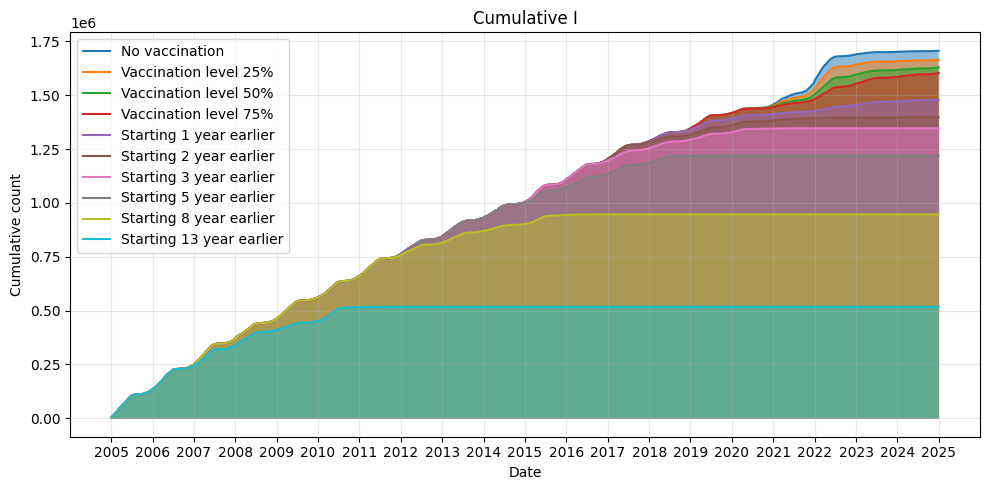

In [40]:
mask = np.ones(len(AGE_STRUCTURED_DATA_INDEX), dtype=bool)
plotting.plot_cumulative_cases(scenarios_with_covid, AGE_STRUCTURED_DATA_INDEX, mask)

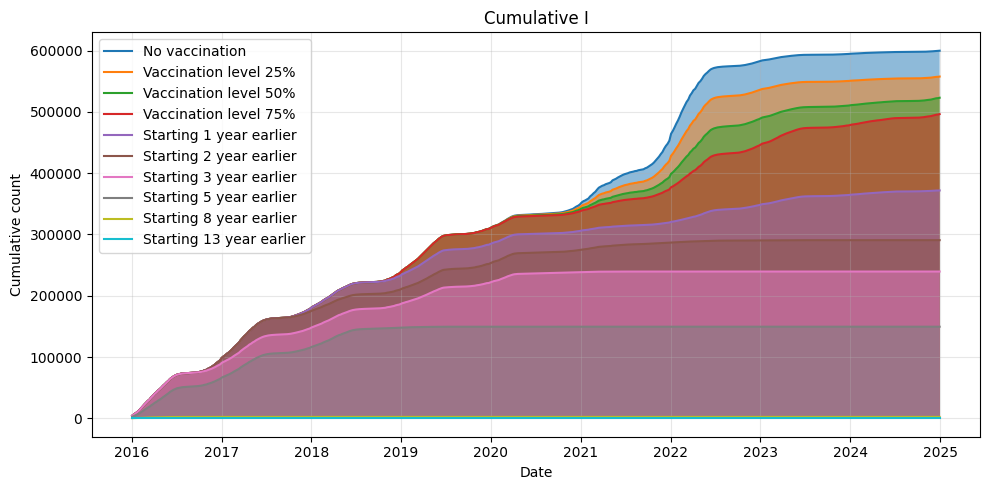

In [41]:
index_after_2016_1_1 = WEEKLY_INDEX[AFTER_2016_1_1_MASK]
plotting.plot_cumulative_cases(scenarios_with_covid, index_after_2016_1_1, AFTER_2016_1_1_MASK)

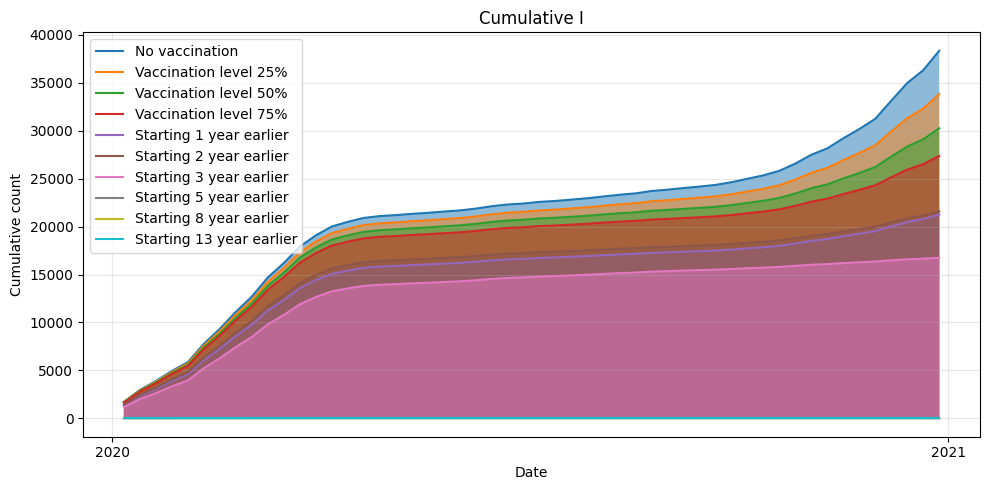

In [42]:
AFTER_2020_1_1_MASK = (WEEKLY_INDEX > pd.Timestamp(2020, 1, 1)) & (WEEKLY_INDEX < pd.Timestamp(2021, 1, 1))
index_after_2020_1_1 = WEEKLY_INDEX[AFTER_2020_1_1_MASK]
plotting.plot_cumulative_cases(scenarios_with_covid, index_after_2020_1_1, AFTER_2020_1_1_MASK)

In [43]:
saved_vacc_level_scenarios = vaccination_level_scenarios + no_covid_scenarios
vacc_level_sensitivity_scenarios: list[Scenario] = [baseline_scenario]
for saved_scenario in saved_vacc_level_scenarios:
    scenario: Scenario = Scenario(saved_scenario.get("name"), I=saved_scenario.get("I"), S=saved_scenario.get("S"), V1=saved_scenario.get("V1"), V2=saved_scenario.get("V2"))
    vacc_level_sensitivity_scenarios.append(scenario)

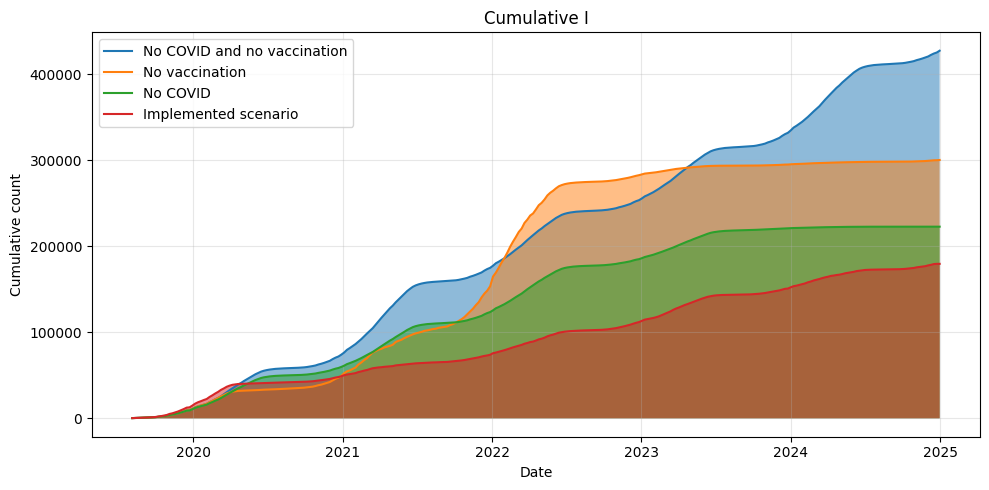

In [44]:
edge_case_mask = WEEKLY_INDEX > pd.Timestamp(2019, 8, 1)
edge_case_index = WEEKLY_INDEX[edge_case_mask]
edge_case_scenario_names = [
    Scenarios.NO_COVID_NO_VACC,
    Scenarios.NO_VACCINATION,
    Scenarios.NO_COVID_BASELINE,
    Scenarios.BASELINE
]

# 1) name -> index map
order_map = {name.value: i for i, name in enumerate(edge_case_scenario_names)}

# 2) filter
edge_case_scenarios = [
    s for s in vacc_level_sensitivity_scenarios
    if s.name in order_map
]

# 3) order
edge_case_scenarios_sorted = sorted(
    edge_case_scenarios,
    key=lambda s: order_map[s.name]
)

# 4) plot
plotting.plot_cumulative_cases(
    edge_case_scenarios_sorted,
    edge_case_index,
    edge_case_mask
)

## Heatmaps

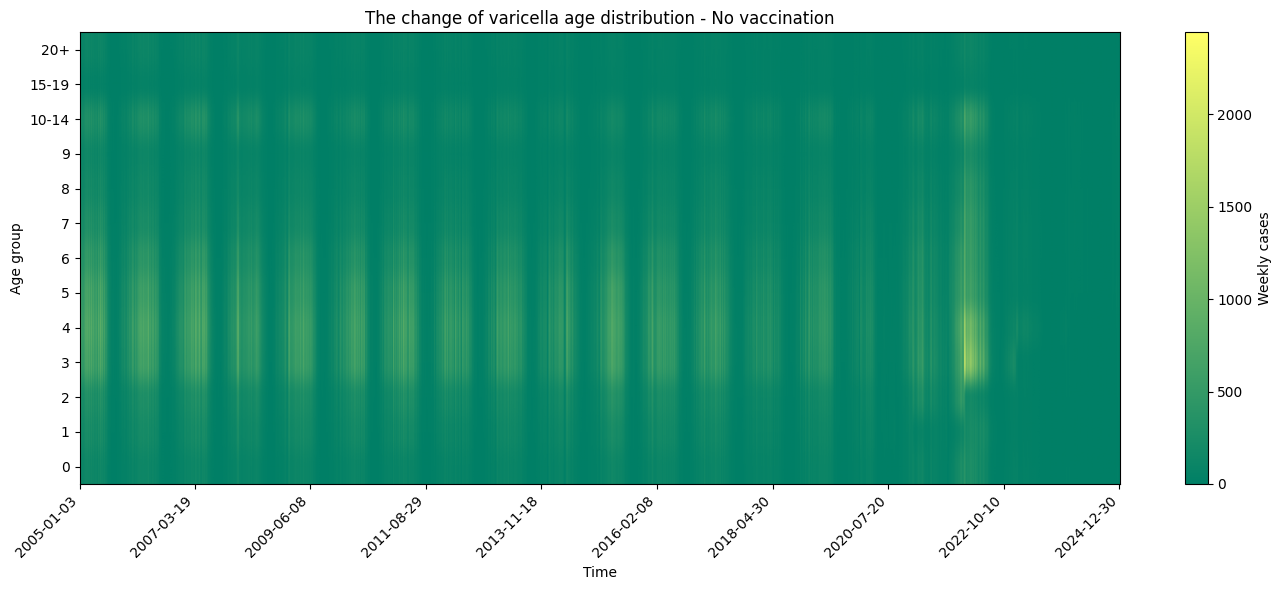

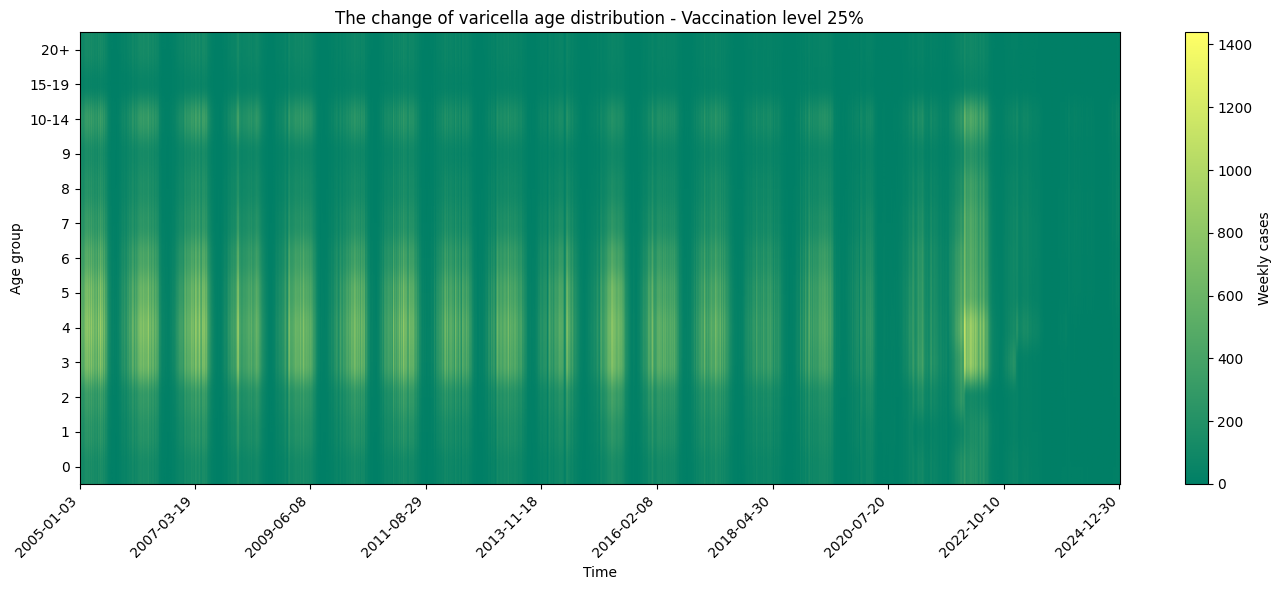

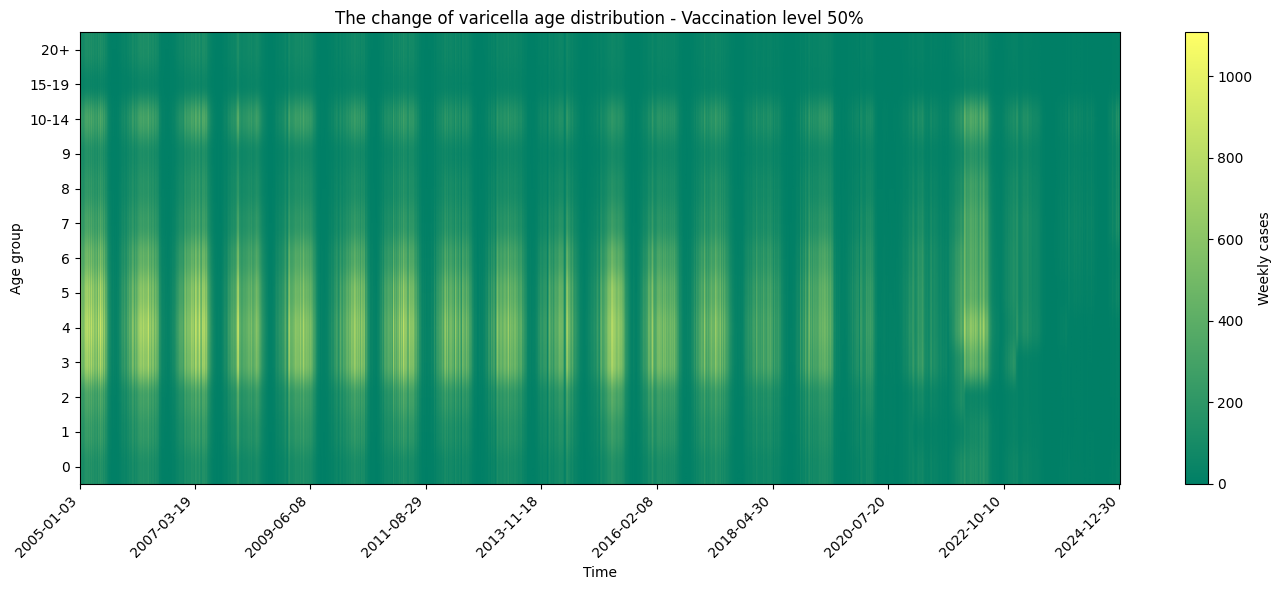

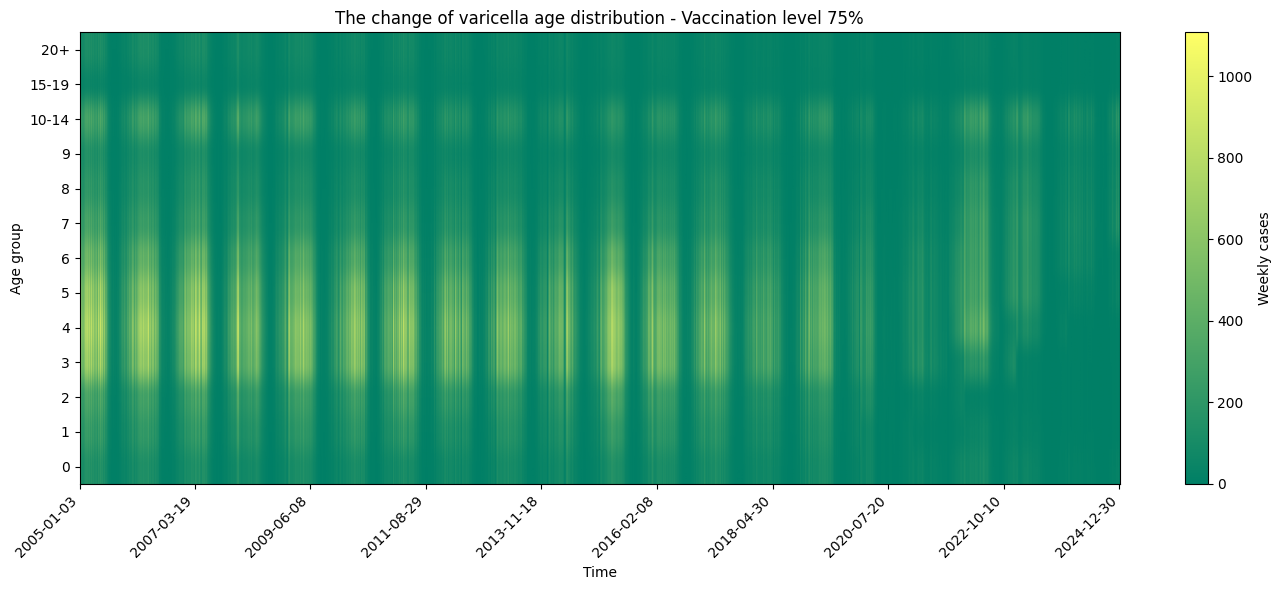

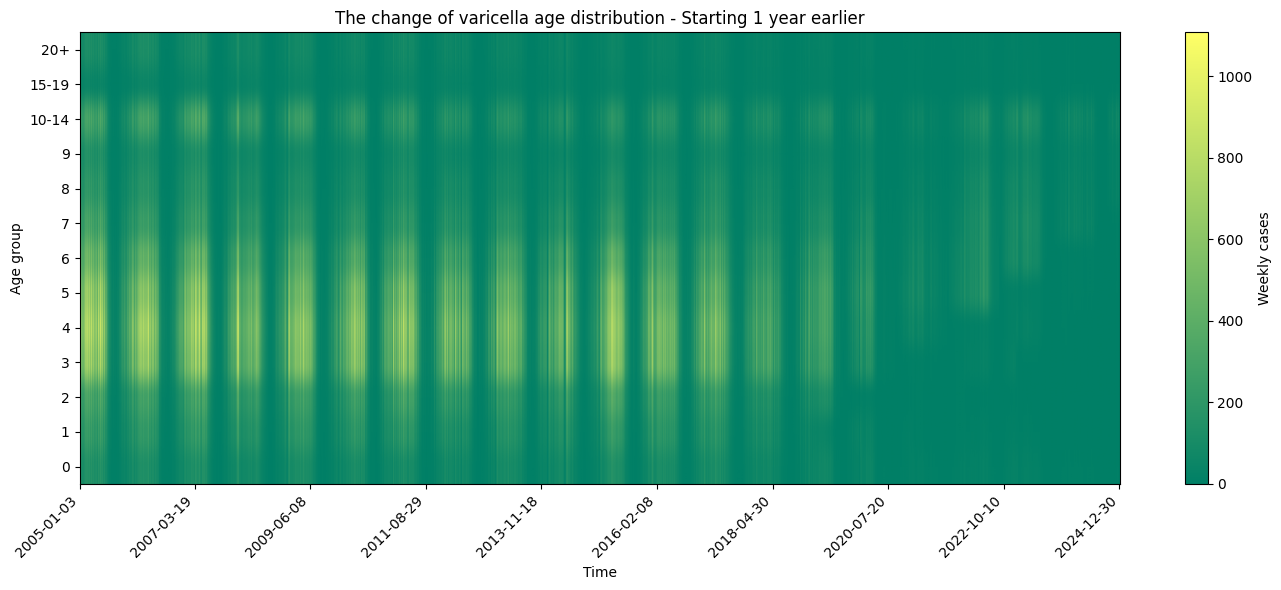

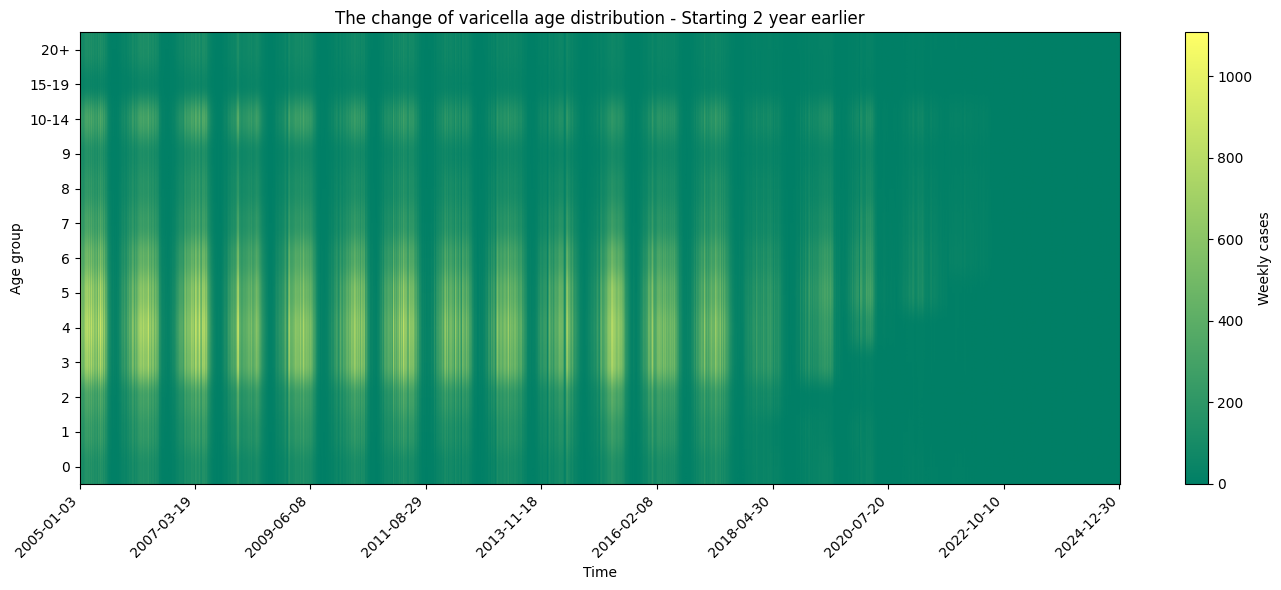

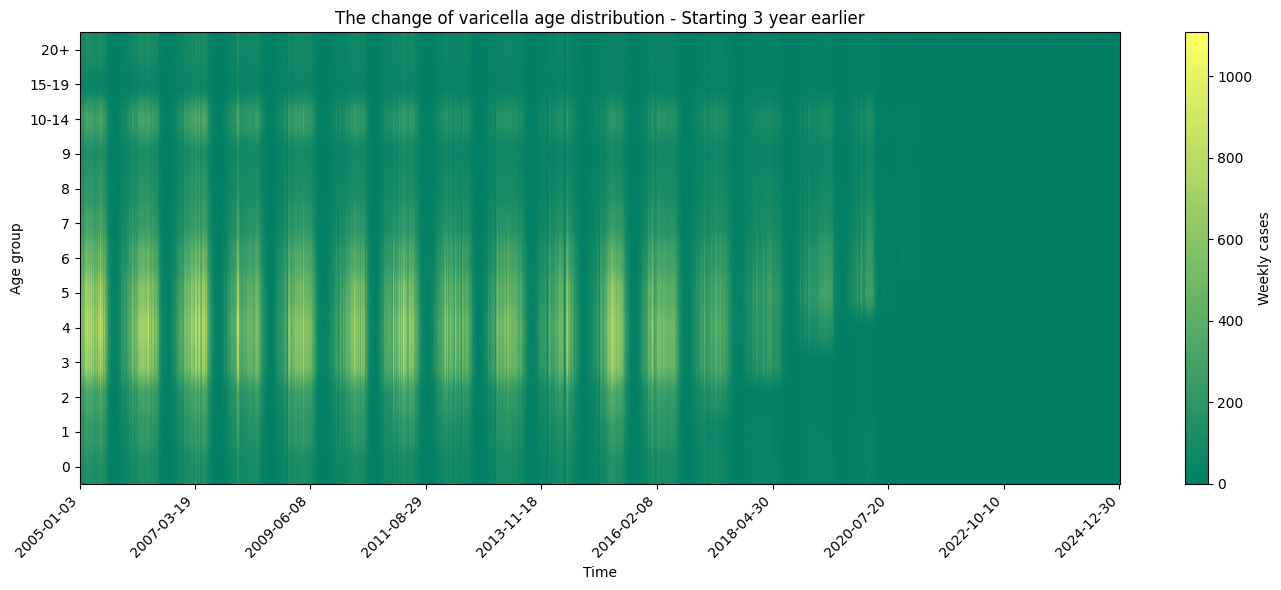

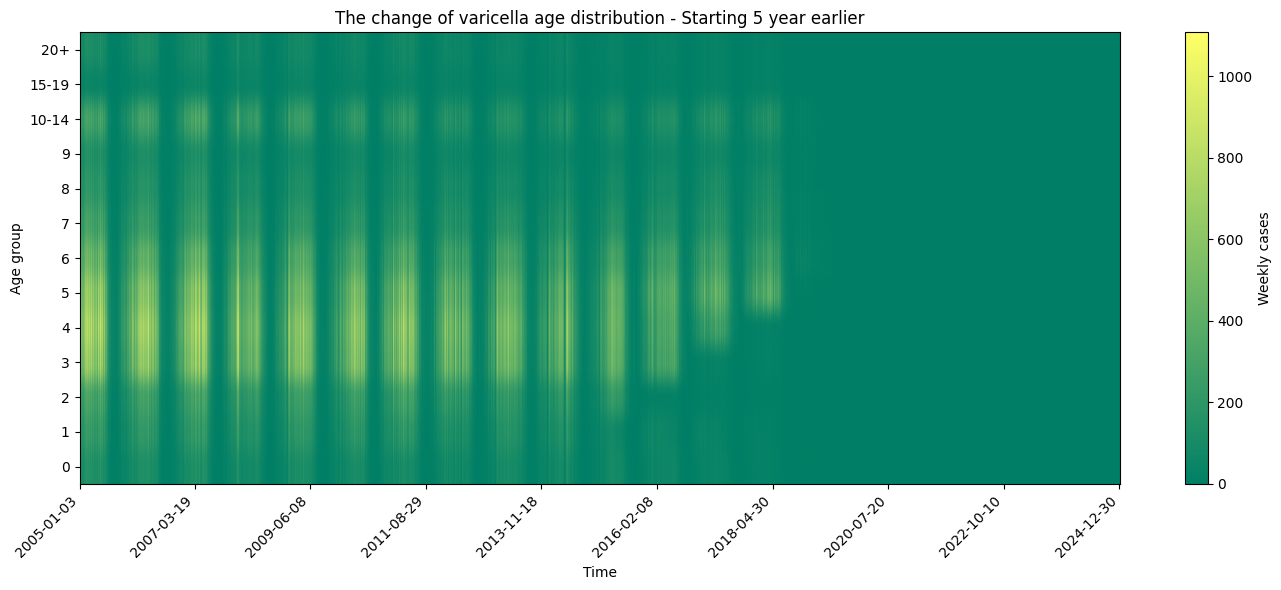

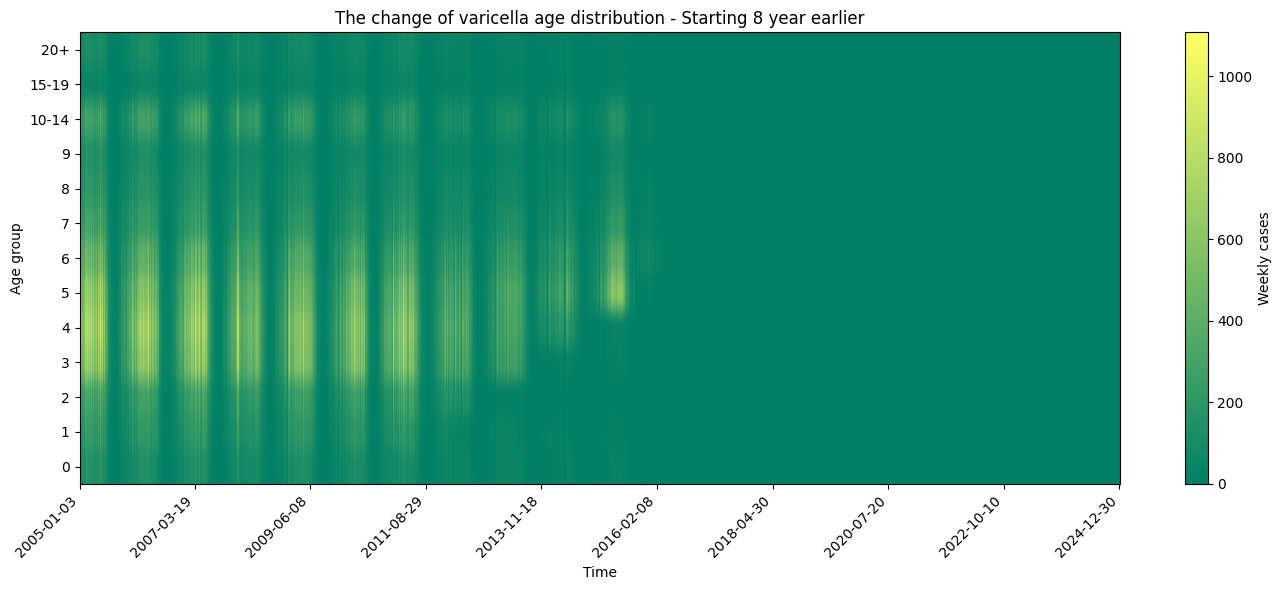

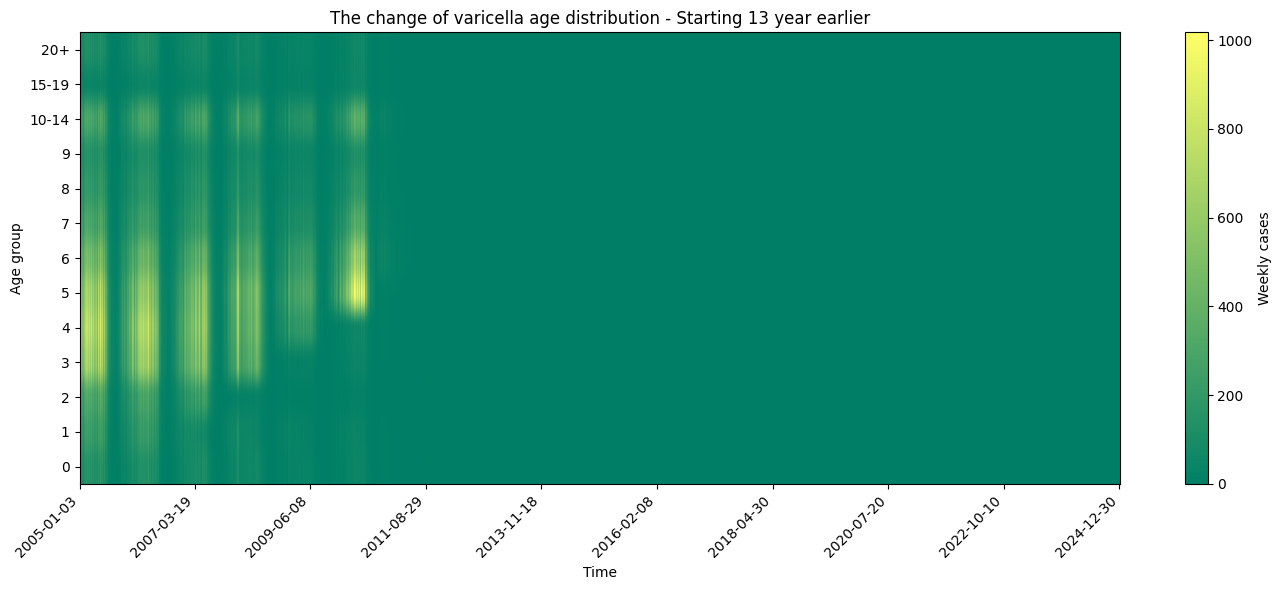

In [45]:
for scenario in scenarios_with_covid:
    df_scenario = pd.DataFrame(scenario.I, index=AGE_GROUPS, columns=WEEKLY_INDEX)
    plotting.plot_heatmap(df_scenario, "The change of varicella age distribution - " + scenario.name)

## Barplots

### Vaccination levels

In [46]:
vacc_level_sensitivity_scenarios: list[Scenario] = []
for saved_scenario in vaccination_level_scenarios:
    scenario: Scenario = Scenario(saved_scenario.get("name"), I=saved_scenario.get("I"), S=saved_scenario.get("S"), V1=saved_scenario.get("V1"), V2=saved_scenario.get("V2"))
    vacc_level_sensitivity_scenarios.append(scenario)
vacc_level_sensitivity_scenarios.append(baseline_scenario)

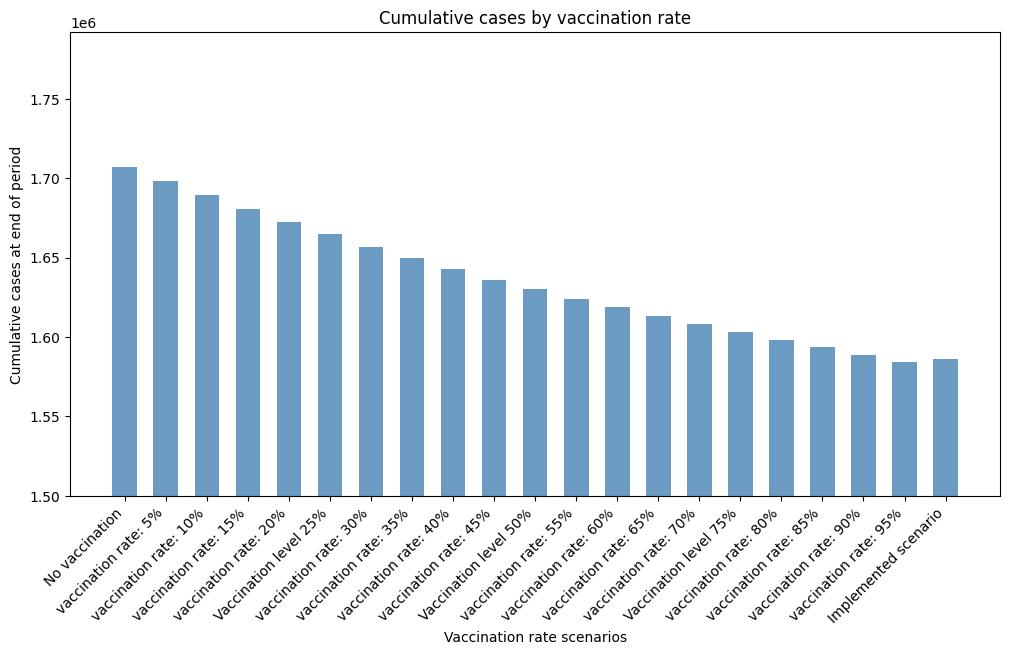

In [47]:
plotting.plot_cumulative_cases_barchart(vacc_level_sensitivity_scenarios)

### Underreporting rate after Covid

In [48]:
saved_detection_rate_related_scenarios = detection_rate_scenarios + [saved_baseline_scenario]
detection_rate_related_scenarios: list[Scenario] = []
vacc_level_100: list[Scenario] = []
vacc_level_75: list[Scenario] = []
vacc_level_25: list[Scenario] = []
vacc_level_10: list[Scenario] = []
vacc_level_0: list[Scenario] = []
for saved_scenario in saved_detection_rate_related_scenarios:
    scenario: Scenario = Scenario(saved_scenario.get("name"), I=saved_scenario.get("I"), S=saved_scenario.get("S"), V1=saved_scenario.get("V1"), V2=saved_scenario.get("V2"))
    scenario.compute_i_series(AGE_STRUCTURED_DATA_INDEX)
    if "Baseline" in scenario.name:
        vacc_level_100.append(scenario)
    elif Scenarios.VACC_LEVEL_75 in scenario.name:
        vacc_level_75.append(scenario)
    elif Scenarios.VACC_LEVEL_25 in scenario.name:
        vacc_level_25.append(scenario)
    elif Scenarios.VACC_LEVEL_10  in scenario.name:
        vacc_level_10.append(scenario)
    elif Scenarios.NO_VACCINATION in scenario.name:
        vacc_level_0.append(scenario)

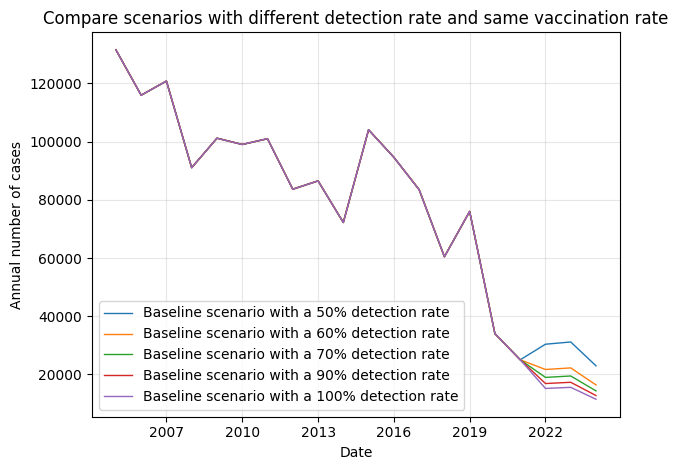

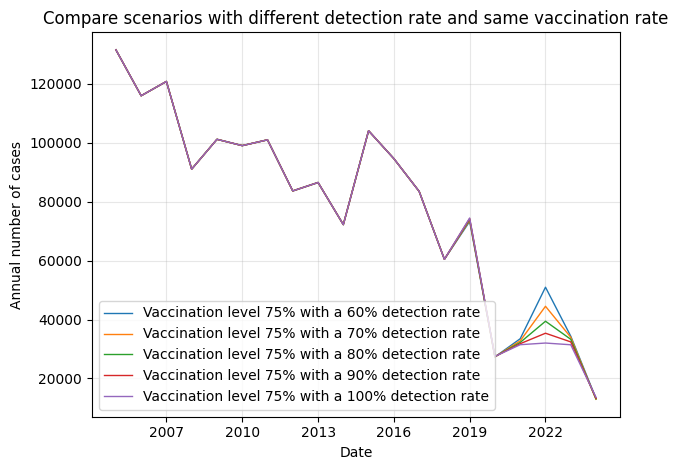

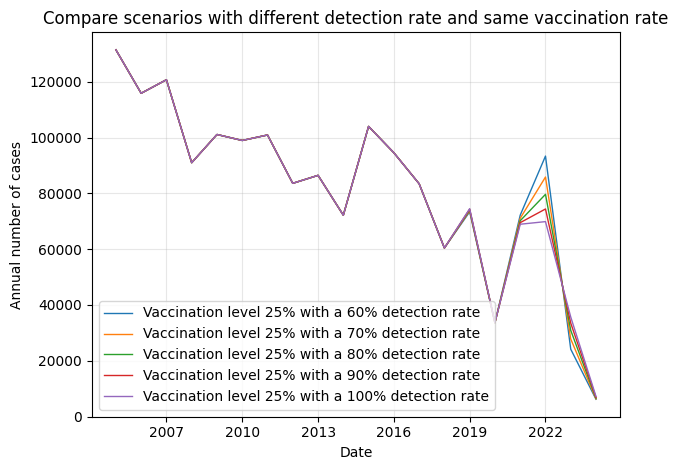

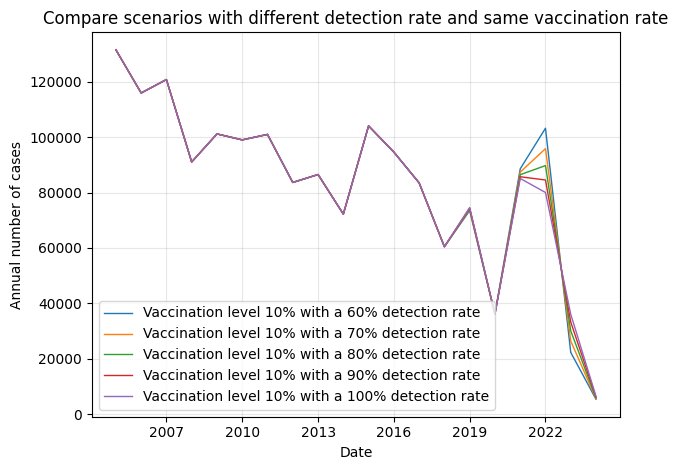

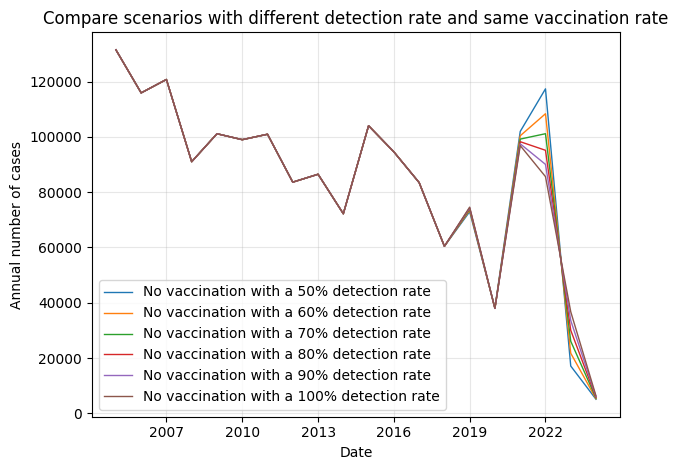

In [50]:
plotting.plot_compare_annual_incidences_for_scenarios(vacc_level_100)
plotting.plot_compare_annual_incidences_for_scenarios(vacc_level_75)
plotting.plot_compare_annual_incidences_for_scenarios(vacc_level_25)
plotting.plot_compare_annual_incidences_for_scenarios(vacc_level_10)
plotting.plot_compare_annual_incidences_for_scenarios(vacc_level_0)